In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import geopandas as gpd
import pandas as pd
import numpy as np
import math
from shapely.geometry import LineString

In [8]:
# Load datasets
journey_links = gpd.read_file('/content/drive/MyDrive/journey_Links_300m.geojson')
air_quality = pd.read_csv('/content/drive/MyDrive/continuous_air_quality_2324.csv', low_memory=False)
journey_counts_filled = pd.read_csv('/content/drive/MyDrive/journey_counts_filled.csv')

# Make sure IDs match
journey_links['JOURNEY_LINK_ID'] = journey_links['JOURNEY_LINK_ID'].astype(int)
journey_counts_filled['JOURNEY_LINK_ID'] = journey_counts_filled['JOURNEY_LINK_ID'].astype(int)

# Keep only journey links that exist in count data
valid_journeys = journey_counts_filled['JOURNEY_LINK_ID'].unique()
journey_links = journey_links[journey_links['JOURNEY_LINK_ID'].isin(valid_journeys)].copy()

# Project to British National Grid metres
journey_links = journey_links.to_crs(epsg=27700)

print(f"Journey links after filtering: {len(journey_links)}")
print(journey_links.crs)



Journey links after filtering: 89
EPSG:27700


In [9]:
# Deduplicate to one row per sensor
sensors = air_quality.drop_duplicates(subset='SITE_ID')[['SITE_ID', 'EASTING', 'NORTHING']].copy()

sensors['SITE_ID'] = sensors['SITE_ID'].astype(int)

sensors_gdf = gpd.GeoDataFrame(
    sensors,
    geometry=gpd.points_from_xy(sensors['EASTING'], sensors['NORTHING']),
    crs='EPSG:27700'
)

print(f"Unique sensors: {len(sensors_gdf)}")
print(sensors_gdf.head())

RADIUS_M = 300

# Create sensor buffers
sensors_buffered = sensors_gdf.copy()
sensors_buffered['geometry'] = sensors_buffered.geometry.buffer(RADIUS_M)

# Spatial join: journey links intersecting each sensor buffer
joined = gpd.sjoin(
    journey_links,
    sensors_buffered[['SITE_ID', 'geometry']],
    how='inner',
    predicate='intersects'
)

# Keep all columns, drop spatial join artifact
road_sensor_pairs = joined.drop(columns='index_right').drop_duplicates().copy()

print(f"Road-sensor pairs within {RADIUS_M}m buffer: {len(road_sensor_pairs)}")

# count the number of journeys per sensor
journeys_per_sensor = (
    road_sensor_pairs
    .groupby('SITE_ID')['JOURNEY_LINK_ID']
    .nunique()
    .reset_index(name='N_JOURNEY_LINKS')
)

print(journeys_per_sensor)


Unique sensors: 8
       SITE_ID  EASTING  NORTHING               geometry
0          203   361178    171566  POINT (361178 171566)
17439      215   358042    170582  POINT (358042 170582)
34873      270   360903    170024  POINT (360903 170024)
52383      452   359488    173924  POINT (359488 173924)
69926      463   362926    175590  POINT (362926 175590)
Road-sensor pairs within 300m buffer: 115
   SITE_ID  N_JOURNEY_LINKS
0      203                7
1      215               12
2      270                4
3      452                8
4      463                6
5      500               53
6      501               15
7      672               10


In [10]:
from shapely.ops import substring
def segmentize_by_angle(line, angle_threshold=8, max_length=30):
    """Split a LineString at bends exceeding angle_threshold degrees,
    then further split any segment longer than max_length metres."""
    coords = list(line.coords)

    if len(coords) < 3:
        # Still enforce max_length on short lines
        return split_by_length(line, max_length)

    segments = []
    current_segment = [coords[0]]

    for i in range(1, len(coords) - 1):
        current_segment.append(coords[i])

        v1 = np.array(coords[i]) - np.array(coords[i - 1])
        v2 = np.array(coords[i + 1]) - np.array(coords[i])

        cos_angle = np.dot(v1, v2) / (
            np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10
        )

        cos_angle = np.clip(cos_angle, -1, 1)
        angle = np.degrees(np.arccos(cos_angle))

        if angle > angle_threshold:
            segments.append(LineString(current_segment))
            current_segment = [coords[i]]

    current_segment.append(coords[-1])

    if len(current_segment) >= 2:
        segments.append(LineString(current_segment))

    # Further split any segment exceeding max_length
    final_segments = []
    for seg in segments:
        final_segments.extend(split_by_length(seg, max_length))

    return final_segments


def split_by_length(line, max_length):
    """Split a LineString into chunks no longer than max_length metres."""
    if line.length <= max_length:
        return [line]

    chunks = []
    current_distance = 0
    total_length = line.length

    while current_distance < total_length:
        start = line.interpolate(current_distance)
        end_distance = min(current_distance + max_length, total_length)
        end = line.interpolate(end_distance)

        # Extract the sub-line between start and end distances
        chunk = substring(line, current_distance, end_distance)
        if not chunk.is_empty and chunk.length > 0:
            chunks.append(chunk)

        current_distance = end_distance

    return chunks


rows = []

for _, row in road_sensor_pairs.iterrows():
    sensor_buffer = sensors_buffered.loc[
        sensors_buffered['SITE_ID'] == row['SITE_ID'], 'geometry'
    ].values[0]

    clipped_geom = row.geometry.intersection(sensor_buffer)

    if clipped_geom.is_empty:
        continue

    geoms = []
    if clipped_geom.geom_type == 'LineString':
        geoms = [clipped_geom]
    elif clipped_geom.geom_type == 'MultiLineString':
        geoms = list(clipped_geom.geoms)
    else:
        geoms = [g for g in clipped_geom.geoms if g.geom_type == 'LineString']

    for geom in geoms:
        segments = segmentize_by_angle(geom, angle_threshold=8, max_length=30)

        for seg_id, seg in enumerate(segments):
            rows.append({
                'JOURNEY_LINK_ID': row['JOURNEY_LINK_ID'],
                'SITE_ID': row['SITE_ID'],
                'SEGMENT_ID': seg_id,
                'SEGMENT_LENGTH': seg.length,
                'geometry': seg
            })

segments_gdf = gpd.GeoDataFrame(rows, crs='EPSG:27700')

print(f"Total segments after clipping to sensor radius: {len(segments_gdf)}")
print(f"Average segment length: {segments_gdf['SEGMENT_LENGTH'].mean():.2f} m")
print(f"Max segment length: {segments_gdf['SEGMENT_LENGTH'].max():.2f} m")  # should be <=30
print(segments_gdf.head())

Total segments after clipping to sensor radius: 1944
Average segment length: 25.09 m
Max segment length: 30.00 m
   JOURNEY_LINK_ID  SITE_ID  SEGMENT_ID  SEGMENT_LENGTH  \
0                9      215           0            30.0   
1                9      215           1            30.0   
2                9      215           2            30.0   
3                9      215           3            30.0   
4                9      215           4            30.0   

                                            geometry  
0  LINESTRING (358271.23 170775.267, 358249.277 1...  
1  LINESTRING (358249.277 170754.821, 358227.323 ...  
2  LINESTRING (358227.323 170734.375, 358205.369 ...  
3  LINESTRING (358205.369 170713.929, 358205.068 ...  
4  LINESTRING (358181.812 170695.355, 358158.233 ...  


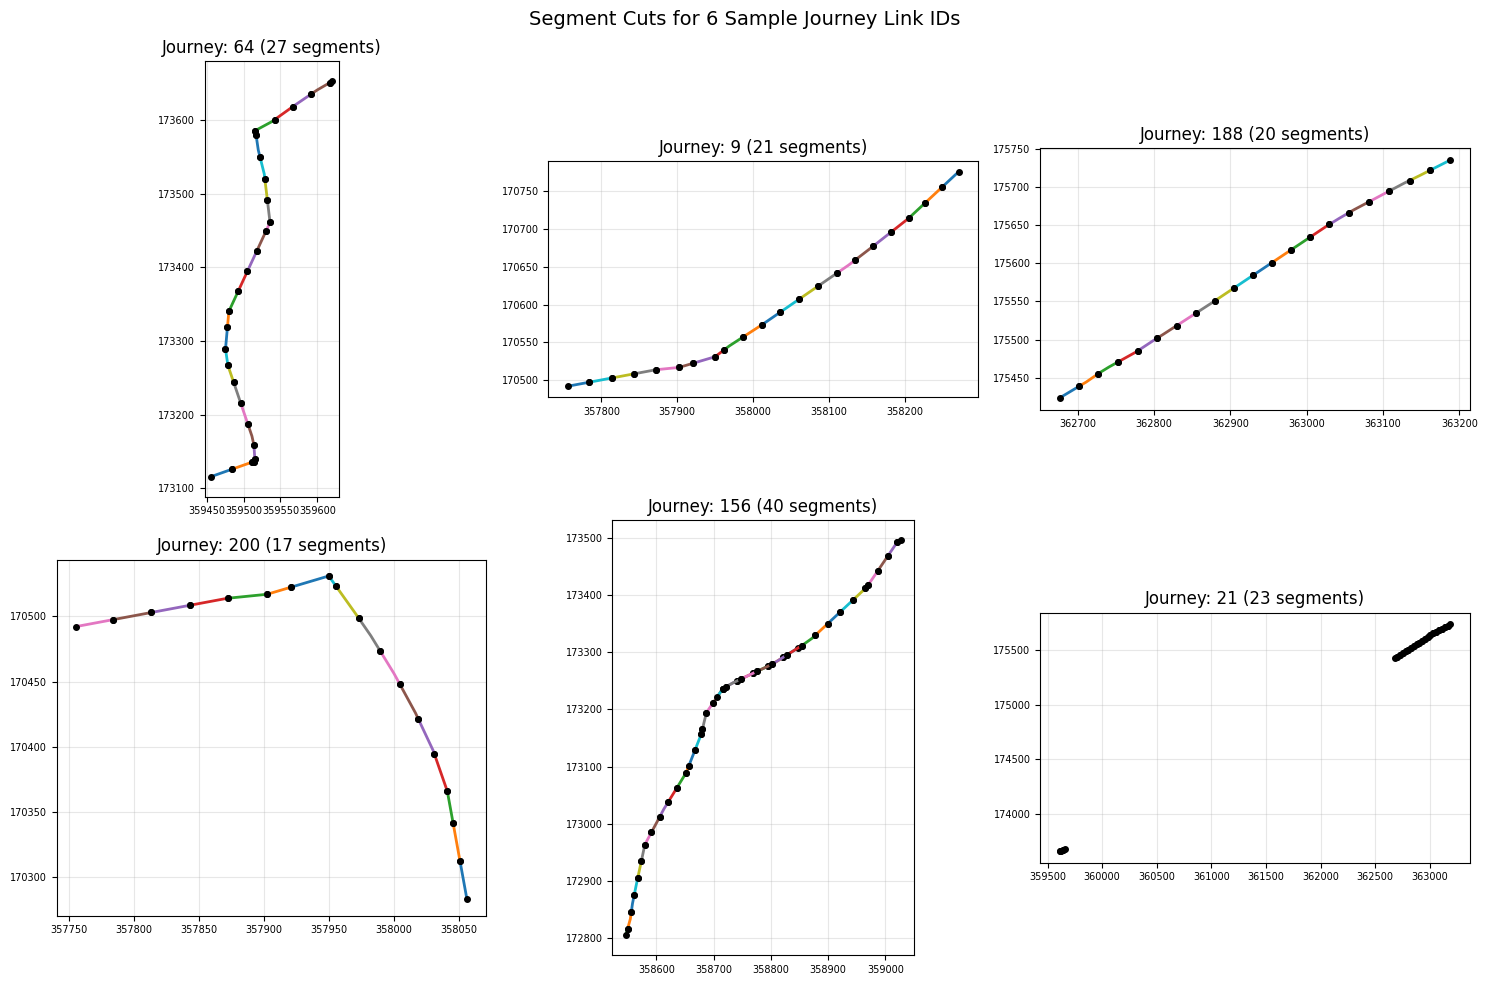

In [ ]:
import matplotlib.pyplot as plt
import random

n_sample = min(6, segments_gdf['JOURNEY_LINK_ID'].nunique())
sample_ids = random.sample(list(segments_gdf['JOURNEY_LINK_ID'].unique()), n_sample)

n_cols = 3
n_rows = math.ceil(n_sample / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

colors = plt.cm.tab10.colors

for i, journey_id in enumerate(sample_ids):
    segs = segments_gdf[segments_gdf['JOURNEY_LINK_ID'] == journey_id]

    for j, (_, seg) in enumerate(segs.iterrows()):
        x, y = seg.geometry.xy
        axes[i].plot(x, y, color=colors[j % len(colors)], linewidth=2)
        axes[i].plot(x[0], y[0], 'ko', markersize=4)
        axes[i].plot(x[-1], y[-1], 'ko', markersize=4)

    axes[i].set_title(f'Journey: {journey_id} ({len(segs)} segments)')
    axes[i].set_aspect('equal')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(labelsize=7)

# Hide any unused axes
for k in range(n_sample, len(axes)):
    axes[k].set_visible(False)

plt.suptitle('Segment Cuts for 6 Sample Journey Link IDs', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1159/2064876962.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(site_ids))


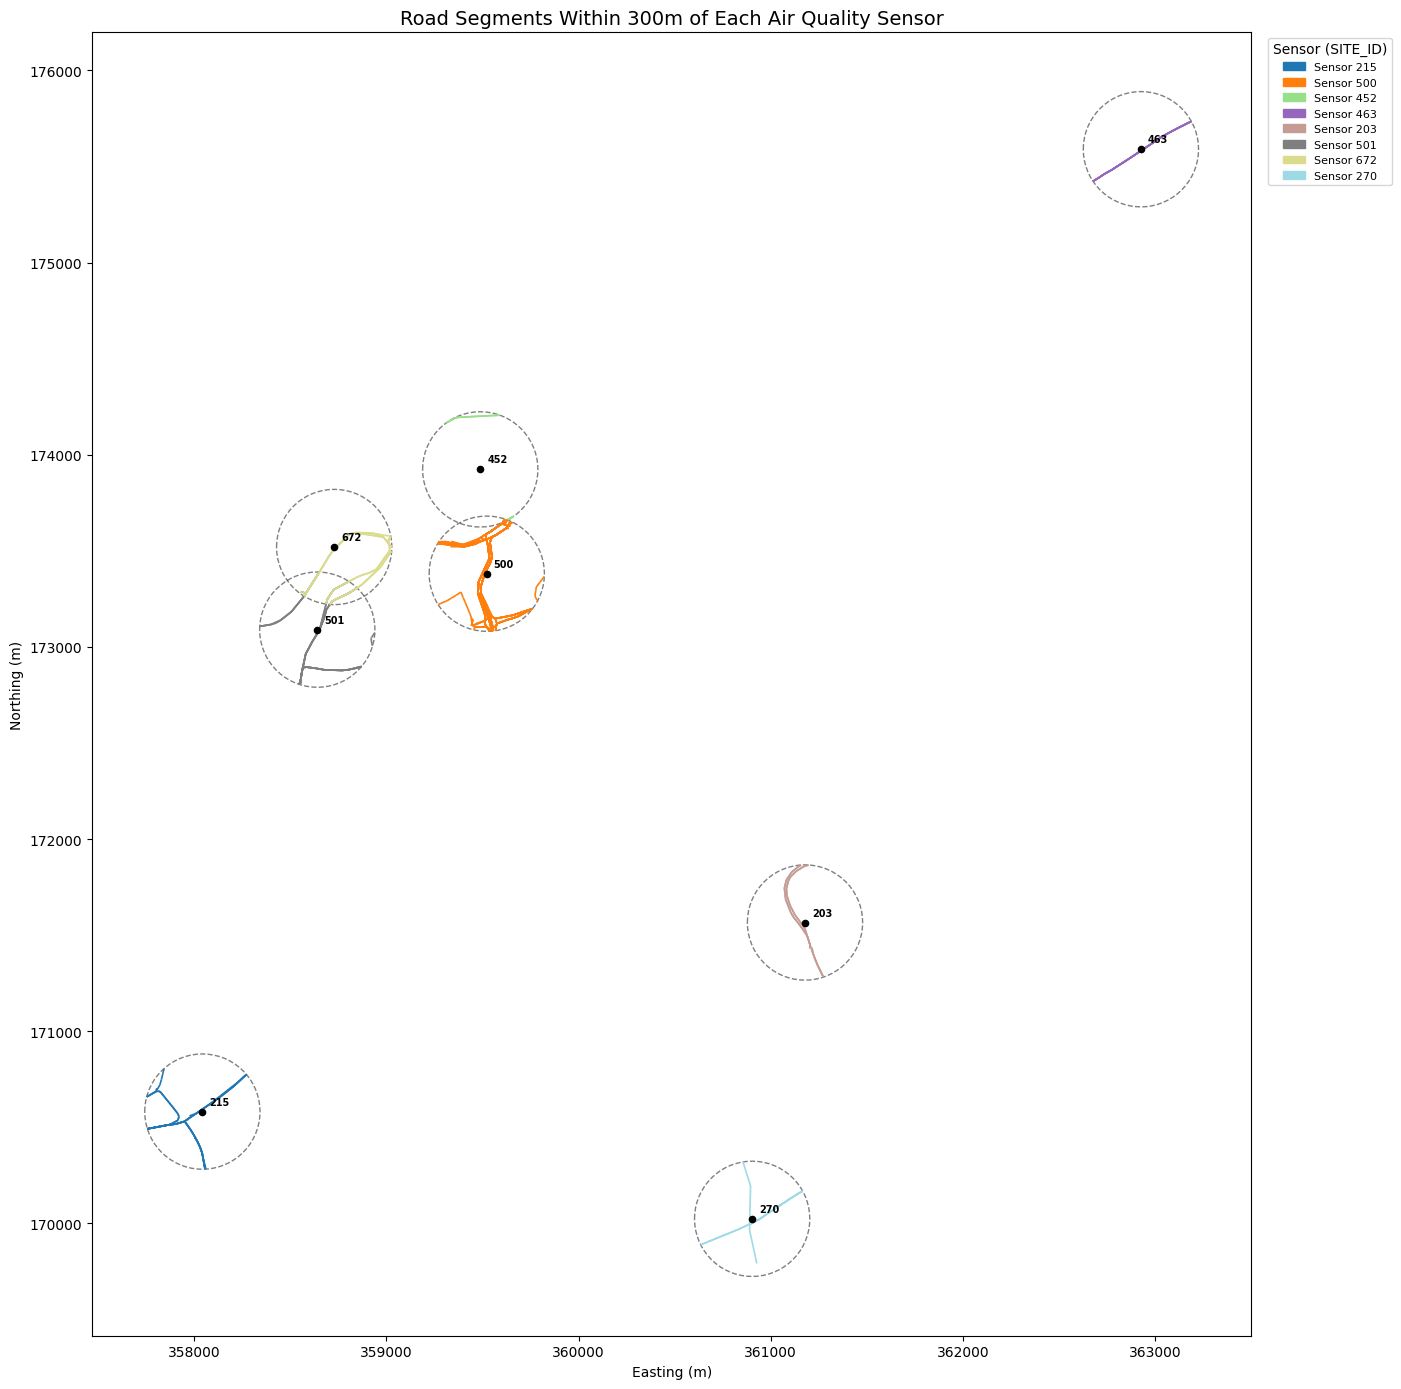

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import numpy as np

# Assign a unique colour to each sensor
site_ids = segments_gdf['SITE_ID'].unique()
cmap = cm.get_cmap('tab20', len(site_ids))
colour_map = {site_id: cmap(i) for i, site_id in enumerate(site_ids)}

fig, ax = plt.subplots(figsize=(14, 14))

# Plot segments coloured by sensor
for site_id, group in segments_gdf.groupby('SITE_ID'):
    gpd.GeoDataFrame(group, crs='EPSG:27700').plot(
        ax=ax,
        color=colour_map[site_id],
        linewidth=1.2,
        label=str(site_id)
    )

# Overlay sensor buffer circles
sensors_buffered_plot = sensors_gdf.copy()
sensors_buffered_plot['geometry'] = sensors_buffered_plot.geometry.buffer(300)
sensors_buffered_plot.plot(
    ax=ax,
    color='none',
    edgecolor='black',
    linewidth=1,
    linestyle='--',
    alpha=0.5
)

# Plot sensor points on top
sensors_gdf.plot(ax=ax, color='black', markersize=20, zorder=5)

# Label each sensor
for _, row in sensors_gdf.iterrows():
    ax.annotate(
        str(row['SITE_ID']),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=7,
        fontweight='bold'
    )

# Legend
patches = [mpatches.Patch(color=colour_map[s], label=f'Sensor {s}') for s in site_ids]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title='Sensor (SITE_ID)')

ax.set_title('Road Segments Within 300m of Each Air Quality Sensor', fontsize=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

In [12]:
# Total length of all segments within each sensor
segments_gdf['LENGTH_PROPORTION'] = (
    segments_gdf['SEGMENT_LENGTH'] /
    segments_gdf.groupby('SITE_ID')['SEGMENT_LENGTH'].transform('sum')
)

# Check proportions sum to 1 per sensor
length_check = (
    segments_gdf
    .groupby('SITE_ID')['LENGTH_PROPORTION']
    .sum()
    .reset_index()
)

print("Length proportion check (should sum to 1.0 per sensor):")
print(length_check)
print(f"\nAll proportions sum to 1: {(length_check['LENGTH_PROPORTION'].round(6) == 1.0).all()}")


Length proportion check (should sum to 1.0 per sensor):
   SITE_ID  LENGTH_PROPORTION
0      203                1.0
1      215                1.0
2      270                1.0
3      452                1.0
4      463                1.0
5      500                1.0
6      501                1.0
7      672                1.0

All proportions sum to 1: True


In [13]:
# Get sensor point geometries as a lookup
sensor_points = sensors_gdf.set_index('SITE_ID')['geometry']

# Calculate distance from each segment's midpoint to its assigned sensor
segments_gdf['DIST_TO_SENSOR'] = segments_gdf.apply(
    lambda row: row.geometry.interpolate(0.5, normalized=True).distance(sensor_points[row['SITE_ID']]),
    axis=1
)

print("Distance to sensor (metres):")
print(segments_gdf[['JOURNEY_LINK_ID', 'SITE_ID', 'DIST_TO_SENSOR']].head())
print(f"\nMax distance: {segments_gdf['DIST_TO_SENSOR'].max():.2f}m")
print(f"Mean distance: {segments_gdf['DIST_TO_SENSOR'].mean():.2f}m")

Distance to sensor (metres):
   JOURNEY_LINK_ID  SITE_ID  DIST_TO_SENSOR
0                9      215      284.850304
1                9      215      254.895573
2                9      215      224.952908
3                9      215      194.989996
4                9      215      164.993285

Max distance: 299.51m
Mean distance: 189.06m


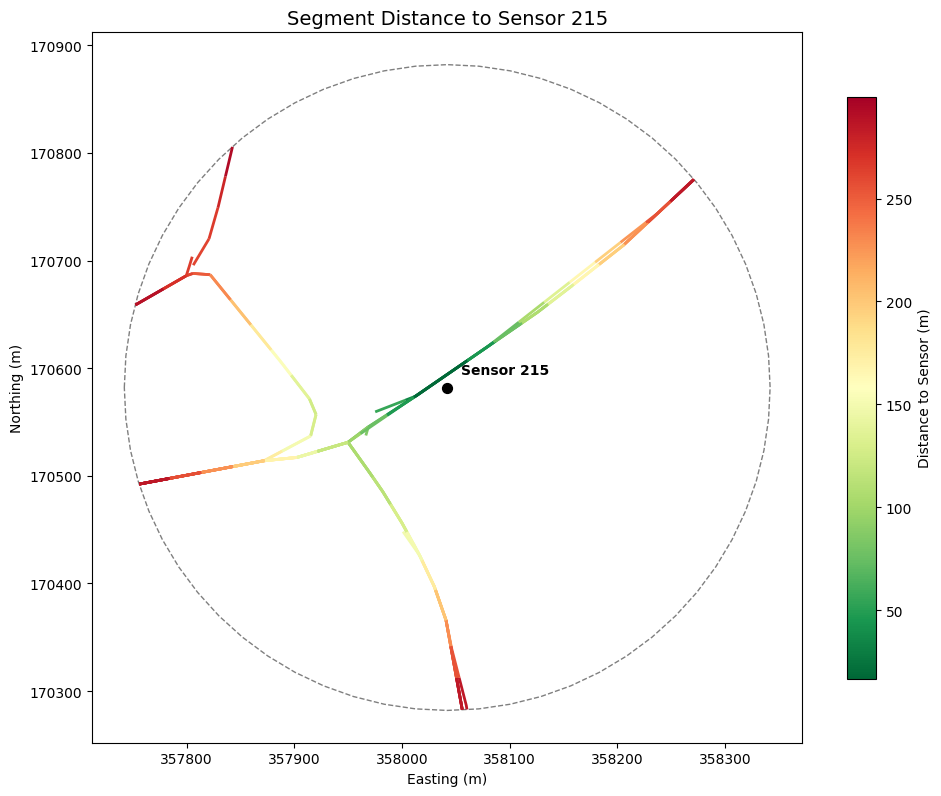

In [ ]:
# Pick a single sensor to visualise
sample_sensor_id = segments_gdf['SITE_ID'].iloc[0]

# Filter segments and sensor for that site
sample_segs = segments_gdf[segments_gdf['SITE_ID'] == sample_sensor_id].copy()
sample_sensor = sensors_gdf[sensors_gdf['SITE_ID'] == sample_sensor_id].copy()
sample_buffer = sample_sensor.copy()
sample_buffer['geometry'] = sample_buffer.geometry.buffer(300)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot buffer boundary
sample_buffer.plot(ax=ax, color='none', edgecolor='black', linestyle='--', linewidth=1, alpha=0.5)

# Plot segments coloured by distance to sensor
sample_segs.plot(
    ax=ax,
    column='DIST_TO_SENSOR',
    cmap='RdYlGn_r',
    linewidth=2,
    legend=True,
    legend_kwds={'label': 'Distance to Sensor (m)', 'shrink': 0.6}
)

# Plot sensor point
sample_sensor.plot(ax=ax, color='black', markersize=50, zorder=5)
ax.annotate(
    f'Sensor {sample_sensor_id}',
    xy=(sample_sensor.geometry.values[0].x, sample_sensor.geometry.values[0].y),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=10,
    fontweight='bold'
)

ax.set_title(f'Segment Distance to Sensor {sample_sensor_id}', fontsize=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

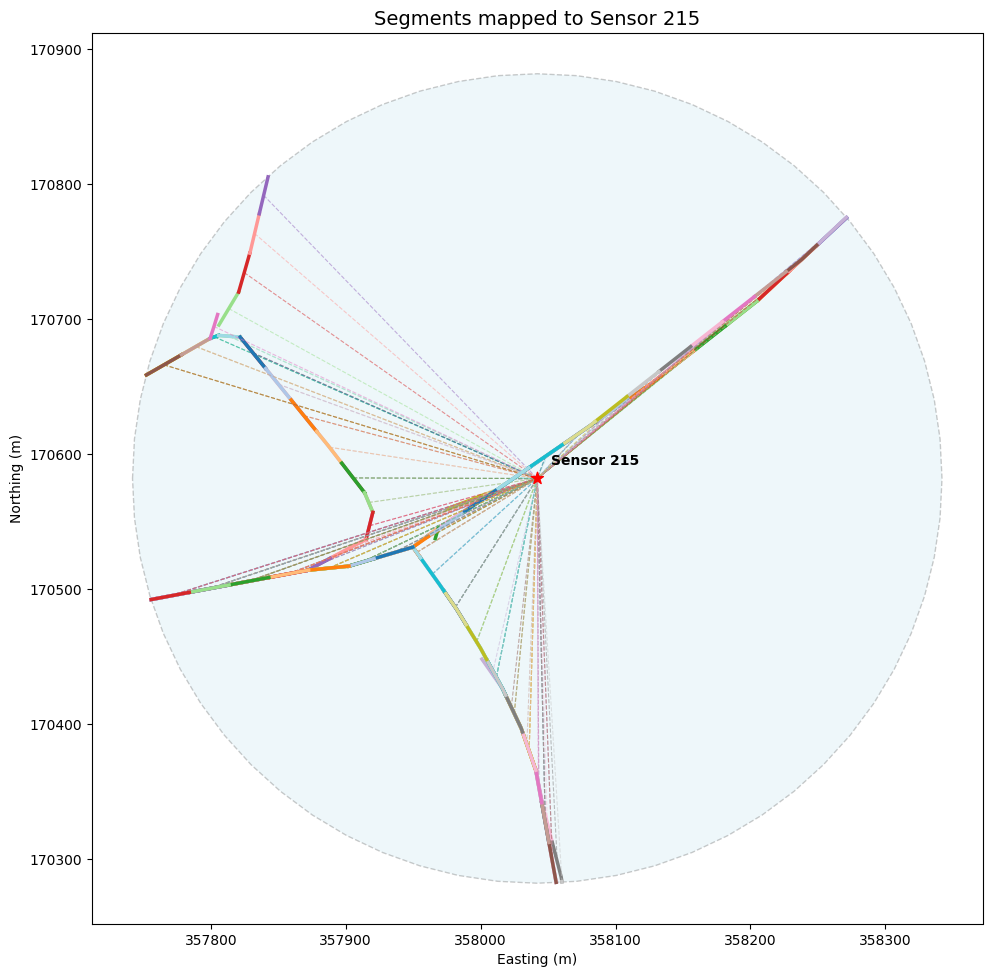

In [ ]:
# Pick a single sensor to visualise
sample_sensor_id = segments_gdf['SITE_ID'].iloc[0]

# Filter segments and sensor for that site
sample_segs = segments_gdf[segments_gdf['SITE_ID'] == sample_sensor_id].copy()
sample_sensor = sensors_gdf[sensors_gdf['SITE_ID'] == sample_sensor_id].copy()
sample_buffer = sample_sensor.copy()
sample_buffer['geometry'] = sample_buffer.geometry.buffer(300)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot buffer boundary
sample_buffer.plot(ax=ax, color='lightblue', edgecolor='black', linestyle='--', linewidth=1, alpha=0.2)

# Assign a unique colour to each segment
cmap = plt.cm.tab20
colours = [cmap(i % 20) for i in range(len(sample_segs))]

sensor_point = sample_sensor.geometry.values[0]
for i, (_, seg) in enumerate(sample_segs.iterrows()):
    x, y = seg.geometry.xy
    ax.plot(x, y, color=colours[i], linewidth=2.5)

    # Dashed line from centroid to sensor
    centroid = seg.geometry.centroid
    ax.plot(
        [centroid.x, sensor_point.x],
        [centroid.y, sensor_point.y],
        color=colours[i], linewidth=0.8, linestyle='--', alpha=0.5
    )

# Plot sensor point
sample_sensor.plot(ax=ax, color='red', markersize=80, zorder=5, marker='*')
ax.annotate(
    f'Sensor {sample_sensor_id}',
    xy=(sensor_point.x, sensor_point.y),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=10,
    fontweight='bold'
)

ax.set_title(f'Segments mapped to Sensor {sample_sensor_id}', fontsize=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

In [14]:
# Ensure both are in EPSG:27700
segments_gdf = segments_gdf.to_crs(epsg=27700)
sensors_gdf = sensors_gdf.to_crs(epsg=27700)

# Get sensor point geometries as a lookup
sensor_points = sensors_gdf.set_index('SITE_ID')['geometry']

# Midpoint coordinates (BNG metres)
midpoints = segments_gdf.geometry.interpolate(0.5, normalized=True)
segments_gdf['MIDPOINT_X'] = midpoints.x
segments_gdf['MIDPOINT_Y'] = midpoints.y

# Sensor coordinates (BNG metres)
segments_gdf['SENSOR_X'] = segments_gdf['SITE_ID'].map(sensor_points.apply(lambda p: p.x))
segments_gdf['SENSOR_Y'] = segments_gdf['SITE_ID'].map(sensor_points.apply(lambda p: p.y))

# Calculate distance from midpoint to sensor
segments_gdf['DIST_TO_SENSOR'] = segments_gdf.apply(
    lambda row: row.geometry.interpolate(0.5, normalized=True).distance(sensor_points[row['SITE_ID']]),
    axis=1
)

print(f"CRS: {segments_gdf.crs}")
print(segments_gdf[['JOURNEY_LINK_ID', 'SITE_ID', 'MIDPOINT_X', 'MIDPOINT_Y', 'SENSOR_X', 'SENSOR_Y', 'DIST_TO_SENSOR']].head())
print(f"\nMax distance: {segments_gdf['DIST_TO_SENSOR'].max():.2f}m")
print(f"Mean distance: {segments_gdf['DIST_TO_SENSOR'].mean():.2f}m")

CRS: EPSG:27700
   JOURNEY_LINK_ID  SITE_ID     MIDPOINT_X     MIDPOINT_Y  SENSOR_X  SENSOR_Y  \
0                9      215  358260.253500  170765.043999  358042.0  170582.0   
1                9      215  358238.299844  170744.598045  358042.0  170582.0   
2                9      215  358216.346189  170724.152092  358042.0  170582.0   
3                9      215  358193.601994  170704.629253  358042.0  170582.0   
4                9      215  358170.022589  170686.081703  358042.0  170582.0   

   DIST_TO_SENSOR  
0      284.850304  
1      254.895573  
2      224.952908  
3      194.989996  
4      164.993285  

Max distance: 299.51m
Mean distance: 189.06m


In [15]:
# wind components
wind_df = pd.read_csv('/content/drive/MyDrive/wind_2023.csv')


# Parse datetime column — replace 'datetime' with your actual column name if different
wind_df['ob_end_time'] = pd.to_datetime(wind_df['ob_end_time'])

# Create a complete expected datetime range at your data's frequency
expected_range = pd.date_range(
    start=wind_df['ob_end_time'].min(),
    end=wind_df['ob_end_time'].max(),
    freq='h'  # change to '30min', '15min' etc if your data is at a different frequency
)

# Find missing timestamps
missing = expected_range.difference(wind_df['ob_end_time'])

print(f"Expected timestamps: {len(expected_range)}")
print(f"Actual timestamps:   {len(wind_df)}")
print(f"Missing timestamps:  {len(missing)}")

if len(missing) > 0:
    print("\nMissing datetimes:")
    print(missing)

Expected timestamps: 8760
Actual timestamps:   8751
Missing timestamps:  9

Missing datetimes:
DatetimeIndex(['2023-03-07 11:00:00', '2023-03-07 12:00:00',
               '2023-03-07 13:00:00', '2023-03-07 14:00:00',
               '2023-03-07 15:00:00', '2023-03-07 16:00:00',
               '2023-08-16 11:00:00', '2023-08-16 12:00:00',
               '2023-08-16 13:00:00'],
              dtype='datetime64[ns]', freq=None)


In [16]:
# Parse and sort by datetime
wind_df['ob_end_time'] = pd.to_datetime(wind_df['ob_end_time'])
wind_df = wind_df.sort_values('ob_end_time').set_index('ob_end_time')

# Reindex to full hourly range to expose any missing timestamps
full_index = pd.date_range(
    start=wind_df.index.min(),
    end=wind_df.index.max(),
    freq='h'
)
wind_df = wind_df.reindex(full_index)

# Interpolate missing wind values
wind_df[['mean_wind_speed', 'mean_wind_dir']] = (
    wind_df[['mean_wind_speed', 'mean_wind_dir']].interpolate(method='time')
)

# Reset index
wind_df = wind_df.reset_index().rename(columns={'index': 'ob_end_time'})

# Checks
print(f"Date range: {wind_df['ob_end_time'].min()} → {wind_df['ob_end_time'].max()}")
print(f"Total rows: {len(wind_df)}")
print(f"Missing values after interpolation:\n{wind_df[['mean_wind_speed', 'mean_wind_dir']].isnull().sum()}")
print(wind_df.head())


Date range: 2023-01-01 00:00:00 → 2023-12-31 23:00:00
Total rows: 8760
Missing values after interpolation:
mean_wind_speed    0
mean_wind_dir      0
dtype: int64
          ob_end_time  mean_wind_speed  mean_wind_dir  wind_to_dir  \
0 2023-01-01 00:00:00             11.0          210.0         30.0   
1 2023-01-01 01:00:00             11.0          210.0         30.0   
2 2023-01-01 02:00:00             10.0          210.0         30.0   
3 2023-01-01 03:00:00              9.0          200.0         20.0   
4 2023-01-01 04:00:00              8.0          190.0         10.0   

  wind_to_sector  
0             NE  
1             NE  
2             NE  
3              N  
4              N  


In [ ]:
wind_df.to_csv('/content/drive/MyDrive/wind_2023_interpolated.csv', index=False)

In [17]:
# split into seperate dataframes
# Split into separate dataframes per sensor
site_ids = segments_gdf['SITE_ID'].unique()

for site_id in site_ids:
    df_name = f'segments_{site_id}'
    globals()[df_name] = segments_gdf[segments_gdf['SITE_ID'] == site_id].copy()
    print(f"{df_name}: {len(globals()[df_name])} segments")

segments_215: 187 segments
segments_500: 963 segments
segments_452: 34 segments
segments_463: 120 segments
segments_203: 102 segments
segments_501: 257 segments
segments_672: 196 segments
segments_270: 85 segments


In [18]:
# Columns to keep
keep_cols = [
    'DATE_TIME', 'JOURNEY_LINK_ID', 'TOTAL_MATCHES_FINAL']

journey_counts_filled = journey_counts_filled[keep_cols].copy()

# Parse datetime
journey_counts_filled['DATE_TIME'] = pd.to_datetime(journey_counts_filled['DATE_TIME'], utc=True)

# Split into one dataframe per sensor by merging with segments to get SITE_ID
journey_counts_with_sensor = journey_counts_filled.merge(
    segments_gdf[['JOURNEY_LINK_ID', 'SITE_ID']].drop_duplicates(),
    on='JOURNEY_LINK_ID',
    how='inner'
)

# Create separate dataframes per sensor and merge with corresponding segments dataframe
for site_id in segments_gdf['SITE_ID'].unique():
    # Traffic counts for this sensor
    counts = journey_counts_with_sensor[journey_counts_with_sensor['SITE_ID'] == site_id].copy()

    # Merge with corresponding segments dataframe
    seg_df = globals()[f'segments_{site_id}']
    merged = counts.merge(
        seg_df[['JOURNEY_LINK_ID', 'SEGMENT_ID', 'SEGMENT_LENGTH', 'LENGTH_PROPORTION',
                'DIST_TO_SENSOR', 'MIDPOINT_X', 'MIDPOINT_Y', 'SENSOR_X', 'SENSOR_Y']],
        on='JOURNEY_LINK_ID',
        how='left'
    )

    globals()[f'traffic_segments_{site_id}'] = merged
    print(f"traffic_segments_{site_id}: {len(merged)} rows, {merged['JOURNEY_LINK_ID'].nunique()} journey links")

traffic_segments_215: 1638731 rows, 12 journey links
traffic_segments_500: 8439278 rows, 53 journey links
traffic_segments_452: 298004 rows, 8 journey links
traffic_segments_463: 1051540 rows, 6 journey links
traffic_segments_203: 893890 rows, 7 journey links
traffic_segments_501: 2252389 rows, 15 journey links
traffic_segments_672: 1717995 rows, 10 journey links
traffic_segments_270: 744732 rows, 4 journey links


In [19]:
# Make wind datetime timezone-aware (UTC) to match traffic data
wind_df['ob_end_time'] = pd.to_datetime(wind_df['ob_end_time']).dt.tz_localize('UTC')

# Add wind vector components
wind_df['theta_rad'] = np.deg2rad(wind_df['wind_to_dir'])
wind_df['wind_x'] = np.sin(wind_df['theta_rad'])
wind_df['wind_y'] = np.cos(wind_df['theta_rad'])

# Merge wind into each sensor's traffic dataframe
for site_id in segments_gdf['SITE_ID'].unique():
    df = globals()[f'traffic_segments_{site_id}']

    merged = df.merge(
        wind_df[['ob_end_time', 'mean_wind_speed', 'mean_wind_dir',
                 'wind_to_dir', 'wind_to_sector', 'wind_x', 'wind_y']],
        left_on='DATE_TIME',
        right_on='ob_end_time',
        how='left'
    ).drop(columns='ob_end_time')  # drop duplicate datetime column

    globals()[f'traffic_segments_{site_id}'] = merged
    print(f"traffic_segments_{site_id}: {len(merged)} rows, "
          f"wind nulls: {merged['mean_wind_speed'].isnull().sum()}")

traffic_segments_215: 1638731 rows, wind nulls: 0
traffic_segments_500: 8439278 rows, wind nulls: 0
traffic_segments_452: 298004 rows, wind nulls: 0
traffic_segments_463: 1051540 rows, wind nulls: 0
traffic_segments_203: 893890 rows, wind nulls: 0
traffic_segments_501: 2252389 rows, wind nulls: 0
traffic_segments_672: 1717995 rows, wind nulls: 0
traffic_segments_270: 744732 rows, wind nulls: 0


In [20]:
for site_id in segments_gdf['SITE_ID'].unique():
    df = globals()[f'traffic_segments_{site_id}']

    # Displacement vector from segment midpoint to sensor
    df['r_x'] = df['SENSOR_X'] - df['MIDPOINT_X']
    df['r_y'] = df['SENSOR_Y'] - df['MIDPOINT_Y']

    # Straight line distance
    df['d'] = df['DIST_TO_SENSOR']

    # Downwind distance (dot product of displacement and wind direction vectors)
    df['x_downwind'] = df['r_x'] * df['wind_x'] + df['r_y'] * df['wind_y']

    # Crosswind distance (perpendicular distance from wind axis)
    df['y_crosswind'] = np.sqrt(
        np.maximum(df['d']**2 - df['x_downwind']**2, 0)
    )

    globals()[f'traffic_segments_{site_id}'] = df
    print(f"traffic_segments_{site_id}: x_downwind range [{df['x_downwind'].min():.1f}, "
          f"{df['x_downwind'].max():.1f}], y_crosswind max {df['y_crosswind'].max():.1f}m")

traffic_segments_215: x_downwind range [-299.0, 299.0], y_crosswind max 299.0m
traffic_segments_500: x_downwind range [-297.2, 297.2], y_crosswind max 297.2m
traffic_segments_452: x_downwind range [-299.3, 299.3], y_crosswind max 299.3m
traffic_segments_463: x_downwind range [-284.8, 284.8], y_crosswind max 284.8m
traffic_segments_203: x_downwind range [-298.7, 298.7], y_crosswind max 298.7m
traffic_segments_501: x_downwind range [-297.2, 297.2], y_crosswind max 297.2m
traffic_segments_672: x_downwind range [-297.9, 297.9], y_crosswind max 297.9m
traffic_segments_270: x_downwind range [-298.8, 298.8], y_crosswind max 298.8m


In [21]:
import numpy as np
import pandas as pd

def compute_plume(
    sigma0=10,
    k=0.1,
    sigma_iso=30,
    calm_threshold=1,
    wind_speed_units="mph"
):
    """
    Compute Gaussian plume weights and traffic NOx index for each sensor.

    Parameters
    ----------
    sigma0 : float
        Initial plume spread near the road, in metres.

    k : float
        Plume spreading rate with downwind distance.

    sigma_iso : float
        Isotropic spread used during calm / low-wind conditions, in metres.

    calm_threshold : float
        Wind speed threshold below which isotropic diffusion is used.
        Use 1 if wind is in mph, or about 0.5 if wind is in m/s.

    wind_speed_units : str
        Only used for printing/documentation.
    """

    for site_id in segments_gdf["SITE_ID"].unique():

        df = globals()[f"traffic_segments_{site_id}"].copy()

        # --------------------------------------------------
        # 1. Safer downwind distance
        # --------------------------------------------------
        # Only positive x contributes to plume growth.
        # Negative x means the sensor is upwind.
        df["x_downwind_positive"] = df["x_downwind"].clip(lower=0)

        # --------------------------------------------------
        # 2. Directional plume spread
        # --------------------------------------------------
        df["sigma_y"] = sigma0 + k * df["x_downwind_positive"]

        # --------------------------------------------------
        # 3. Directional plume weight
        # --------------------------------------------------
        df["plume_weight_directional"] = np.where(
            df["x_downwind"] > 0,
            (1 / df["sigma_y"]) * np.exp(
                -(df["y_crosswind"] ** 2) / (2 * df["sigma_y"] ** 2)
            ),
            0
        )

        # --------------------------------------------------
        # 4. Isotropic Gaussian fallback for calm wind
        # --------------------------------------------------
        # Uses radial distance from segment midpoint to sensor.
        # This is used when wind direction is unreliable.
        df["plume_weight_isotropic"] = (
            (1 / sigma_iso)
            * np.exp(
                -(df["DIST_TO_SENSOR"] ** 2) / (2 * sigma_iso ** 2)
            )
        )

        # --------------------------------------------------
        # 5. Choose model based on wind speed
        # --------------------------------------------------
        df["is_calm"] = df["mean_wind_speed"] < calm_threshold

        df["plume_weight"] = np.where(
            df["is_calm"],
            df["plume_weight_isotropic"],
            df["plume_weight_directional"]
        )

        # --------------------------------------------------
        # 6. Traffic contribution
        # --------------------------------------------------
        df["traffic_contribution"] = (
            df["TOTAL_MATCHES_FINAL"]
            * df["LENGTH_PROPORTION"]
            * df["plume_weight"]
        )

        # --------------------------------------------------
        # 7. Aggregate to hourly sensor index
        # --------------------------------------------------
        sensor_hourly = (
            df.groupby(["SITE_ID", "DATE_TIME"])["traffic_contribution"]
            .sum()
            .reset_index(name="traffic_nox_index")
        )

        # Save back to global variables
        globals()[f"traffic_segments_{site_id}"] = df
        globals()[f"sensor_hourly_{site_id}"] = sensor_hourly

        calm_hours = (
            df.loc[df["is_calm"], "DATE_TIME"]
            .nunique()
        )

        print(
            f"sensor_hourly_{site_id}: {len(sensor_hourly)} hourly rows, "
            f"mean NOx index: {sensor_hourly['traffic_nox_index'].mean():.4f}, "
            f"calm hours: {calm_hours}"
        )

    print("\nParameters used:")
    print(f"sigma0 = {sigma0}")
    print(f"k = {k}")
    print(f"sigma_iso = {sigma_iso}")
    print(f"calm_threshold = {calm_threshold} {wind_speed_units}")


# Recommended baseline
compute_plume(
    sigma0=5,
    k=0.05,
    sigma_iso=30,
    calm_threshold=1,      # use 1 if wind speed is mph
    wind_speed_units="mph"
)

sensor_hourly_215: 8760 hourly rows, mean NOx index: 0.2113, calm hours: 19
sensor_hourly_500: 8760 hourly rows, mean NOx index: 0.1131, calm hours: 19
sensor_hourly_452: 8760 hourly rows, mean NOx index: 0.0105, calm hours: 19
sensor_hourly_463: 8760 hourly rows, mean NOx index: 0.0799, calm hours: 19
sensor_hourly_203: 8760 hourly rows, mean NOx index: 0.2756, calm hours: 19
sensor_hourly_501: 8760 hourly rows, mean NOx index: 0.2105, calm hours: 19
sensor_hourly_672: 8760 hourly rows, mean NOx index: 0.2061, calm hours: 19
sensor_hourly_270: 8760 hourly rows, mean NOx index: 0.0612, calm hours: 19

Parameters used:
sigma0 = 5
k = 0.05
sigma_iso = 30
calm_threshold = 1 mph


In [18]:
sensor_hourly_215.to_csv('/content/drive/MyDrive/pollution_215.csv', index=False)
sensor_hourly_500.to_csv('/content/drive/MyDrive/pollution_500.csv', index=False)
sensor_hourly_452.to_csv('/content/drive/MyDrive/pollution_452.csv', index=False)
sensor_hourly_463.to_csv('/content/drive/MyDrive/pollution_463.csv', index=False)
sensor_hourly_203.to_csv('/content/drive/MyDrive/pollution_203.csv', index=False)
sensor_hourly_501.to_csv('/content/drive/MyDrive/pollution_501.csv', index=False)
sensor_hourly_672.to_csv('/content/drive/MyDrive/pollution_672.csv', index=False)
sensor_hourly_270.to_csv('/content/drive/MyDrive/pollution_270.csv', index=False)


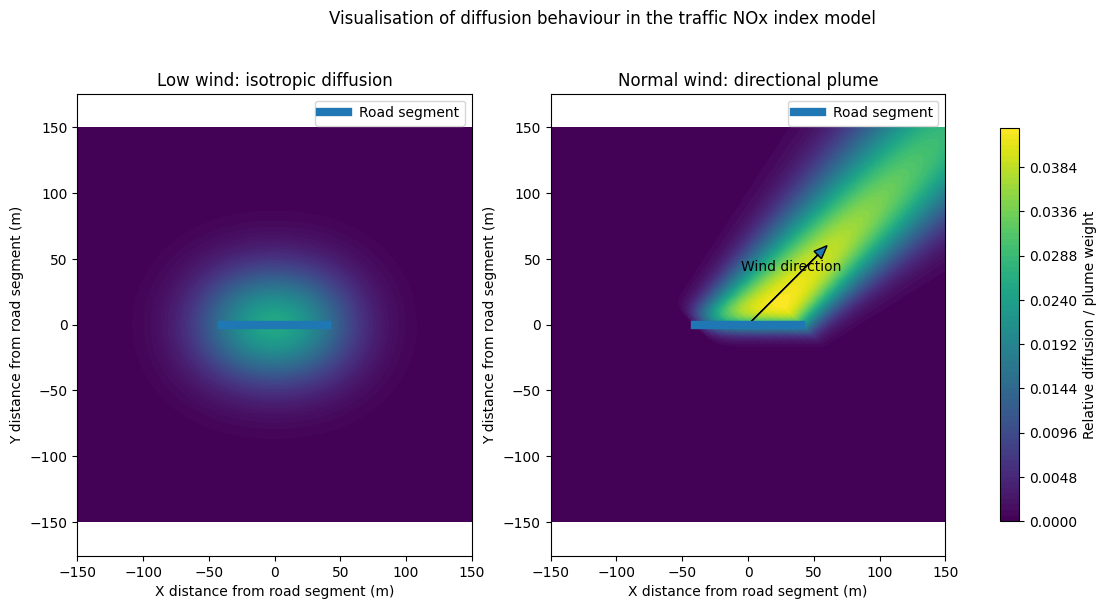

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
sigma0 = 10
k = 0.1
sigma_iso = 30
wind_to_dir = 45  # wind blowing towards NE

# Road segment for visual
seg_x1, seg_y1 = -40, 0
seg_x2, seg_y2 = 40, 0

# Grid
x = np.linspace(-150, 150, 350)
y = np.linspace(-150, 150, 350)
X, Y = np.meshgrid(x, y)

# Wind vector: 0=N, 90=E
theta = np.deg2rad(wind_to_dir)
wind_x = np.sin(theta)
wind_y = np.cos(theta)

# Sample points along road just for visual smoothness
n_points = 40
source_xs = np.linspace(seg_x1, seg_x2, n_points)
source_ys = np.linspace(seg_y1, seg_y2, n_points)

W_iso_total = np.zeros_like(X)
W_plume_total = np.zeros_like(X)

for sx, sy in zip(source_xs, source_ys):
    rx = X - sx
    ry = Y - sy
    d = np.sqrt(rx**2 + ry**2)

    # Low wind: circular diffusion
    W_iso = (1 / sigma_iso) * np.exp(-(d**2) / (2 * sigma_iso**2))

    # Normal wind: directional plume
    x_downwind = rx * wind_x + ry * wind_y
    y_crosswind = np.sqrt(np.maximum(d**2 - x_downwind**2, 0))
    sigma_y = sigma0 + k * np.clip(x_downwind, 0, None)

    W_plume = np.where(
        x_downwind > 0,
        (1 / sigma_y) * np.exp(-(y_crosswind**2) / (2 * sigma_y**2)),
        0
    )

    W_iso_total += W_iso / n_points
    W_plume_total += W_plume / n_points

# Use shared colour scale for fair visual comparison
vmax = max(W_iso_total.max(), W_plume_total.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -----------------------------
# Low wind plot
# -----------------------------
im0 = axes[0].contourf(X, Y, W_iso_total, levels=80, vmin=0, vmax=vmax)
axes[0].plot([seg_x1, seg_x2], [seg_y1, seg_y2], linewidth=6, label="Road segment")
axes[0].set_title("Low wind: isotropic diffusion")
axes[0].set_xlabel("X distance from road segment (m)")
axes[0].set_ylabel("Y distance from road segment (m)")
axes[0].axis("equal")
axes[0].legend(loc="upper right")

# -----------------------------
# Normal wind plot
# -----------------------------
im1 = axes[1].contourf(X, Y, W_plume_total, levels=80, vmin=0, vmax=vmax)
axes[1].plot([seg_x1, seg_x2], [seg_y1, seg_y2], linewidth=6, label="Road segment")

# Wind arrow
arrow_len = 85
axes[1].arrow(
    0, 0,
    arrow_len * wind_x,
    arrow_len * wind_y,
    head_width=8,
    head_length=10,
    length_includes_head=True
)

axes[1].text(
    arrow_len * wind_x * 0.55,
    arrow_len * wind_y * 0.55 + 8,
    "Wind direction",
    ha="center"
)

axes[1].set_title("Normal wind: directional plume")
axes[1].set_xlabel("X distance from road segment (m)")
axes[1].set_ylabel("Y distance from road segment (m)")
axes[1].axis("equal")
axes[1].legend(loc="upper right")

# Shared colorbar
cbar = fig.colorbar(im1, ax=axes, shrink=0.85)
cbar.set_label("Relative diffusion / plume weight")

plt.suptitle("Visualisation of diffusion behaviour in the traffic NOx index model", y=1.02)
plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sensor_diffusion(
    site_id,
    wind_to_dir=45,
    sigma0=10,
    k=0.1,
    sigma_iso=30,
    mode="directional",
    grid_buffer=350,
    grid_res=300
):
    df = globals()[f"traffic_segments_{site_id}"].copy()

    segs = (
        df[[
            "SEGMENT_ID",
            "MIDPOINT_X",
            "MIDPOINT_Y",
            "LENGTH_PROPORTION"
        ]]
        .drop_duplicates("SEGMENT_ID")
        .copy()
    )

    sensor_row = gdf_sensor[gdf_sensor["SITE_ID"] == site_id].iloc[0]
    sensor_x = sensor_row.geometry.x
    sensor_y = sensor_row.geometry.y

    x = np.linspace(sensor_x - grid_buffer, sensor_x + grid_buffer, grid_res)
    y = np.linspace(sensor_y - grid_buffer, sensor_y + grid_buffer, grid_res)
    X, Y = np.meshgrid(x, y)

    theta = np.deg2rad(wind_to_dir)
    wind_x = np.sin(theta)
    wind_y = np.cos(theta)

    W_total = np.zeros_like(X, dtype=float)

    for _, row in segs.iterrows():
        sx = row["MIDPOINT_X"]
        sy = row["MIDPOINT_Y"]
        length_weight = row["LENGTH_PROPORTION"]

        rx = X - sx
        ry = Y - sy
        d = np.sqrt(rx**2 + ry**2)

        if mode == "isotropic":
            W = (1 / sigma_iso) * np.exp(-(d**2) / (2 * sigma_iso**2))

        elif mode == "directional":
            x_downwind = rx * wind_x + ry * wind_y
            y_crosswind = np.sqrt(np.maximum(d**2 - x_downwind**2, 0))
            sigma_y = sigma0 + k * np.clip(x_downwind, 0, None)

            W = np.where(
                x_downwind > 0,
                (1 / sigma_y) * np.exp(
                    -(y_crosswind**2) / (2 * sigma_y**2)
                ),
                0
            )
        else:
            raise ValueError("mode must be 'directional' or 'isotropic'")

        W_total += length_weight * W

    plt.figure(figsize=(9, 8))
    contour = plt.contourf(X, Y, W_total, levels=80)
    plt.colorbar(contour, label="Relative plume / diffusion weight")

    # Plot segment midpoints
    plt.scatter(
        segs["MIDPOINT_X"],
        segs["MIDPOINT_Y"],
        s=20,
        label="Segment midpoints"
    )

    # Plot sensor
    plt.scatter(
        sensor_x,
        sensor_y,
        marker="*",
        s=220,
        label=f"Sensor {site_id}"
    )

    if mode == "directional":
        arrow_len = 120
        plt.arrow(
            sensor_x,
            sensor_y,
            arrow_len * wind_x,
            arrow_len * wind_y,
            head_width=20,
            head_length=25,
            length_includes_head=True
        )

    plt.title(f"Sensor {site_id}: {mode} plume field")
    plt.xlabel("Easting (m)")
    plt.ylabel("Northing (m)")
    plt.axis("equal")
    plt.legend()
    plt.show()

In [30]:
plot_sensor_diffusion(site_id=215, wind_to_dir=45, mode="directional")

NameError: name 'gdf_sensor' is not defined

In [28]:
traffic_segments_203.head()

,DATE_TIME,JOURNEY_LINK_ID,TOTAL_MATCHES_FINAL,SITE_ID,SEGMENT_ID,SEGMENT_LENGTH,LENGTH_PROPORTION,DIST_TO_SENSOR,MIDPOINT_X,MIDPOINT_Y,...,d,x_downwind,y_crosswind,x_downwind_positive,sigma_y,plume_weight_directional,plume_weight_isotropic,is_calm,plume_weight,traffic_contribution
0,2023-01-01 00:00:00+00:00,136,73.0,203,0,30.000000,0.011855,284.814196,361267.054497,171295.466411,...,284.814196,189.761713,212.390251,189.761713,14.488086,1.488996e-48,8.930687e-22,False,1.488996e-48,1.288580e-48
1,2023-01-01 00:00:00+00:00,136,73.0,203,1,30.000000,0.011855,255.098510,361254.049872,171322.501198,...,255.098510,172.851212,187.610522,172.851212,13.642561,6.304099e-43,6.635393e-18,False,6.304099e-43,5.455578e-43
2,2023-01-01 00:00:00+00:00,136,73.0,203,2,30.000000,0.011855,225.427747,361241.247031,171349.626522,...,225.427747,155.761414,162.960275,155.761414,12.788071,4.276897e-37,1.827512e-14,False,4.276897e-37,3.701234e-37
3,2023-01-01 00:00:00+00:00,136,73.0,203,3,30.000000,0.011855,195.608750,361229.965797,171377.420205,...,195.608750,137.331994,139.293598,137.331994,11.866600,1.012756e-31,1.954505e-11,False,1.012756e-31,8.764405e-32
4,2023-01-01 00:00:00+00:00,136,73.0,203,4,19.011667,0.007513,171.199394,361221.523538,171400.425443,...,171.199394,121.630004,120.479769,121.630004,11.081500,1.939950e-27,2.826846e-09,False,1.939950e-27,1.063915e-27


In [ ]:
param_results = []

sigma0_values = [5, 10, 20]
k_values = [0.05, 0.1, 0.2]

def safe_divide(num, denom):
    if denom == 0 or pd.isna(denom):
        return np.nan
    return num / denom

for sigma0 in sigma0_values:
    for k in k_values:

        compute_plume(
            sigma0=sigma0,
            k=k,
            sigma_iso=30,
            calm_threshold=1,
            wind_speed_units="mph"
        )

        sensor_rows = []

        for site_id in segments_gdf["SITE_ID"].unique():
            df = globals()[f"traffic_segments_{site_id}"]
            hourly = globals()[f"sensor_hourly_{site_id}"]

            # 1. Non-zero rate
            nonzero_rate = (df["traffic_contribution"] > 0).mean()

            # 2. Segment dominance
            seg_sum = df.groupby("SEGMENT_ID")["traffic_contribution"].sum()
            top_segment_share = safe_divide(seg_sum.max(), seg_sum.sum())

            # 3. Near/far contribution per match
            near = df[df["DIST_TO_SENSOR"] <= 50]
            far = df[(df["DIST_TO_SENSOR"] > 200) & (df["DIST_TO_SENSOR"] <= 300)]

            near_per_match = safe_divide(
                near["traffic_contribution"].sum(),
                near["TOTAL_MATCHES_FINAL"].sum()
            )

            far_per_match = safe_divide(
                far["traffic_contribution"].sum(),
                far["TOTAL_MATCHES_FINAL"].sum()
            )

            near_far_ratio = safe_divide(near_per_match, far_per_match)

            # 4. Correlation with total traffic
            hourly_traffic = (
                df.groupby(["SITE_ID", "DATE_TIME"])["TOTAL_MATCHES_FINAL"]
                .sum()
                .reset_index(name="total_matches")
            )

            merged = hourly.merge(
                hourly_traffic,
                on=["SITE_ID", "DATE_TIME"],
                how="left"
            )

            corr_traffic = merged["traffic_nox_index"].corr(
                merged["total_matches"]
            )

            sensor_rows.append({
                "sigma0": sigma0,
                "k": k,
                "SITE_ID": site_id,
                "nonzero_rate": nonzero_rate,
                "top_segment_share": top_segment_share,
                "near_far_ratio": near_far_ratio,
                "corr_with_traffic": corr_traffic
            })

        sensor_df = pd.DataFrame(sensor_rows)

        param_results.append({
            "sigma0": sigma0,
            "k": k,
            "mean_nonzero_rate": sensor_df["nonzero_rate"].mean(skipna=True),
            "max_top_segment_share": sensor_df["top_segment_share"].max(skipna=True),
            "mean_near_far_ratio": sensor_df["near_far_ratio"].mean(skipna=True),
            "mean_corr_with_traffic": sensor_df["corr_with_traffic"].mean(skipna=True)
        })

param_summary = pd.DataFrame(param_results)
param_summary

sensor_hourly_215: 8760 hourly rows, mean NOx index: 0.2113, calm hours: 19
sensor_hourly_500: 8760 hourly rows, mean NOx index: 0.1131, calm hours: 19
sensor_hourly_452: 8760 hourly rows, mean NOx index: 0.0105, calm hours: 19
sensor_hourly_463: 8760 hourly rows, mean NOx index: 0.0799, calm hours: 19
sensor_hourly_203: 8760 hourly rows, mean NOx index: 0.2756, calm hours: 19
sensor_hourly_501: 8760 hourly rows, mean NOx index: 0.2105, calm hours: 19
sensor_hourly_672: 8760 hourly rows, mean NOx index: 0.2061, calm hours: 19
sensor_hourly_270: 8760 hourly rows, mean NOx index: 0.0612, calm hours: 19

Parameters used:
sigma0 = 5
k = 0.05
sigma_iso = 30
calm_threshold = 1 mph
sensor_hourly_215: 8760 hourly rows, mean NOx index: 0.2044, calm hours: 19
sensor_hourly_500: 8760 hourly rows, mean NOx index: 0.1117, calm hours: 19
sensor_hourly_452: 8760 hourly rows, mean NOx index: 0.0107, calm hours: 19
sensor_hourly_463: 8760 hourly rows, mean NOx index: 0.0780, calm hours: 19
sensor_hourl

,sigma0,k,mean_nonzero_rate,max_top_segment_share,mean_near_far_ratio,mean_corr_with_traffic
0,5,0.05,0.481963,0.293594,14.526037,0.389446
1,5,0.10,0.493452,0.302526,14.806662,0.434754
2,5,0.20,0.499774,0.304595,14.903859,0.506584
3,10,0.05,0.507086,0.300706,14.923015,0.446818
4,10,0.10,0.507086,0.302476,14.899272,0.491087
5,10,0.20,0.507086,0.305406,14.632792,0.561651
6,20,0.05,0.507086,0.302349,12.823560,0.524172
7,20,0.10,0.507086,0.302893,12.632725,0.562078
8,20,0.20,0.507086,0.307014,12.205717,0.622055


In [ ]:
traffic_segments_203